# Stage 3 · Step 02 — Strategy 1: end-to-end rolled-out classification

For each training feature $z$, run the complete $T$-step Euler rollout to get $\hat z$, push
it through the **frozen** classifier, and minimise

$$\mathcal{L}_\mathrm{cls} = \mathrm{CE}(W\hat z + b,\; y)$$

backpropagating through the whole rollout and updating **only** the flow's parameters.

The flow starts at identity (step 01), so before any gradient step the complete system *is*
the Stage 1 linear probe. Every number below is a difference against that.

Section 2 measures something that turns out to govern the entire result, so it comes before
any training.

## 1 · Setup

In [1]:
from __future__ import annotations

import time

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from cvlab.data import make_kshot_subset
from cvlab.evaluation import summarize_runs
from cvlab.features import load_features
from cvlab.plotting import ArtifactWriter, apply_style
from cvlab3 import COMBOS, K_SHOT, SEEDS, T_STEPS, FrozenClassifier
from cvlab3.paths import RESULTS_ROOT, describe, step_dirs
from cvlab3.training import EndToEndConfig, train_end_to_end

apply_style()
PLOTS, TABLES = step_dirs("02_end_to_end")
art = ArtifactWriter(PLOTS, TABLES)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

setup = torch.load(RESULTS_ROOT / "frozen_classifiers.pt", map_location="cpu",
                   weights_only=False)
assert setup["verification"]["max_abs_delta_pp_vs_stage1"] == 0.0
assert setup["verification"]["identity_init_exact"]
print("step 01 artefacts verified:", setup["verification"])
print(f"\ndevice = {DEVICE}   |   K = {K_SHOT}   |   T = {T_STEPS}   |   seeds = {SEEDS}")

step 01 artefacts verified: {'max_abs_delta_pp_vs_stage1': 0.0, 'predictions_identical': True, 'identity_init_exact': True}

device = cuda   |   K = 10   |   T = 4   |   seeds = (0, 1, 2)


In [2]:
# Load every split once; all 81 runs below reuse these tensors.
FEATURES = {}
for encoder, dataset in COMBOS:
    FEATURES[(encoder, dataset)] = {
        split: load_features(encoder, dataset, split) for split in ("train", "val", "test")
    }

COMBO_LABEL = {("resnet18", "DTD"): "ResNet-18 / DTD",
               ("dinov2", "FGVC-Aircraft"): "DINOv2 / Aircraft",
               ("resnet18", "FGVC-Aircraft"): "ResNet-18 / Aircraft"}
ORDER = [COMBO_LABEL[c] for c in COMBOS]


def case(encoder, dataset, seed):
    # Everything one run needs: the frozen classifier and its exact Stage 1 data.
    key = f"{encoder}__{dataset}__K{K_SHOT}__seed{seed}"
    payload = setup["classifiers"][key]
    bundles = FEATURES[(encoder, dataset)]
    x, y = make_kshot_subset(bundles["train"].features, bundles["train"].labels, K_SHOT, seed)
    clf = FrozenClassifier.from_state_dict(payload["state_dict"]).to(DEVICE)
    return key, payload, clf, x, y, bundles


print(f"{len(FEATURES)} combinations loaded")

3 combinations loaded


## 2 · The objective is nearly exhausted before training starts

The loss being minimised is the classification loss of the frozen probe **on the probe's own
training set** — the same 470 or 1000 k-shot features it was fitted on in Stage 1. So before
running anything, it is worth asking how much of that loss is left to remove.

In [3]:
criterion = nn.CrossEntropyLoss()
rows = []
for encoder, dataset in COMBOS:
    for seed in SEEDS:
        key, payload, clf, x, y, bundles = case(encoder, dataset, seed)
        with torch.no_grad():
            xg, yg = x.to(DEVICE), y.to(DEVICE)
            tr_logits = clf(xg)
            va_logits = clf(bundles["val"].features.to(DEVICE))
            vay = bundles["val"].labels.to(DEVICE)
            rows.append({
                "encoder": encoder, "dataset": dataset, "seed": seed,
                "train_acc": (tr_logits.argmax(1) == yg).float().mean().item(),
                "val_acc": (va_logits.argmax(1) == vay).float().mean().item(),
                "test_acc": payload["stage1_test_acc"],
                "ce_train": criterion(tr_logits, yg).item(),
                "ce_val": criterion(va_logits, vay).item(),
                "n_train": x.shape[0],
            })

diag = pd.DataFrame(rows)
diag["ce_ratio"] = diag["ce_val"] / diag["ce_train"]
diag_summary = (diag.groupby(["encoder", "dataset"])
                    [["train_acc", "val_acc", "test_acc", "ce_train", "ce_val", "ce_ratio"]]
                    .mean().reset_index())
art.table(diag, "objective_diagnostic")
art.table(diag_summary, "objective_diagnostic_summary")

print("The frozen probe, evaluated at identity (i.e. the Stage 3 system before training):\n")
for _, r in diag_summary.iterrows():
    print(f"  {r['encoder']:>9} / {r['dataset']:<14}  "
          f"train {r['train_acc']*100:6.2f}%   val {r['val_acc']*100:6.2f}%   "
          f"CE(train) {r['ce_train']:7.4f}   CE(val) {r['ce_val']:6.4f}   "
          f"ratio {r['ce_ratio']:6.1f}x")
diag_summary

  saved table -> tables/objective_diagnostic.csv  (9 rows)
  saved table -> tables/objective_diagnostic_summary.csv  (3 rows)
The frozen probe, evaluated at identity (i.e. the Stage 3 system before training):

     dinov2 / FGVC-Aircraft   train 100.00%   val  52.11%   CE(train)  0.0052   CE(val) 2.3044   ratio  449.3x
   resnet18 / DTD             train  98.44%   val  51.52%   CE(train)  0.3266   CE(val) 1.8234   ratio    7.2x
   resnet18 / FGVC-Aircraft   train 100.00%   val  27.67%   CE(train)  0.0307   CE(val) 3.5729   ratio  122.4x


,encoder,dataset,train_acc,val_acc,test_acc,ce_train,ce_val,ce_ratio
0,dinov2,FGVC-Aircraft,1.000000,0.521052,0.515352,0.005185,2.304426,449.265758
1,resnet18,DTD,0.984397,0.515248,0.520390,0.326646,1.823387,7.221687
2,resnet18,FGVC-Aircraft,1.000000,0.276728,0.278728,0.030706,3.572900,122.437471


**The probe already fits its own training set at 96–100%**, and on DINOv2/Aircraft the
training cross-entropy is **0.005** — three decimal places from zero. Validation
cross-entropy is 7× to 450× larger.

That gap governs this step, but it is worth being precise about what it does and does not
imply. It does **not** mean there is no gradient to follow: section 6 shows the flow drives
training cross-entropy all the way down to $10^{-6}$, so there is plenty of signal. It means
that *following that signal is memorisation* — the remaining training loss is removed by
growing more confident about features the classifier already classifies correctly.

So the question Strategy 1 actually poses is not "can the flow reduce the loss" (it can,
completely) but **"how little can it be allowed to move before memorisation outweighs whatever
real structure it finds"**. Each configuration below is a different answer: the default
settings, two smaller learning rates, and the two regularisers the brief suggests.

## 3 · The main configuration

Optimiser settings mirror Stage 1's probe and Stage 2's flow where they overlap (AdamW,
lr $10^{-3}$, weight decay $10^{-4}$, batch 64) rather than introducing new numbers.
Gradient clipping at 1.0 is carried over from Stage 2, which found that backpropagating
through $T$ composed Euler steps can amplify gradients enough to diverge.

Checkpoint selection is on **validation accuracy** — Stage 1's own rule, and the fair one
here because both Stage 3 strategies produce directly comparable validation accuracies.

In [4]:
def run_grid(config: EndToEndConfig, tag: str, combos=COMBOS, verbose: bool = True):
    # Train one configuration over every (combination, seed) and return tidy rows.
    out, curves = [], {}
    for encoder, dataset in combos:
        for seed in SEEDS:
            key, payload, clf, x, y, bundles = case(encoder, dataset, seed)
            r = train_end_to_end(
                payload["dim"], clf, x, y,
                bundles["val"].features, bundles["val"].labels,
                bundles["test"].features, bundles["test"].labels,
                seed=seed, baseline_acc=payload["stage1_test_acc"],
                T=T_STEPS, config=config, device=DEVICE,
            )
            out.append({
                "config": tag, "encoder": encoder, "dataset": dataset, "seed": seed,
                "lr": config.lr,
                "displacement_weight": config.displacement_weight,
                "velocity_weight": config.velocity_weight,
                "baseline_acc": r.baseline_acc, "test_acc": r.test_acc,
                "delta_pp": r.delta_pp, "best_val_acc": r.best_val_acc,
                "best_epoch": r.best_epoch, "final_train_loss": r.final_train_loss,
                "mean_displacement": r.mean_displacement,
                "relative_displacement": r.relative_displacement,
                "n_params": r.n_params, "elapsed_s": r.elapsed_s,
            })
            curves[f"{tag}__{key}"] = r.history
    if verbose:
        df = pd.DataFrame(out)
        print(f"  {tag:<28} mean delta = {df['delta_pp'].mean():+6.2f} pp   "
              f"median best epoch = {df['best_epoch'].median():5.0f}   "
              f"({df['elapsed_s'].sum():.0f}s)")
    return out, curves


MAIN = EndToEndConfig()
print("Main configuration:")
for k, v in MAIN.as_dict().items():
    print(f"  {k:<24} {v}")

Main configuration:
  hidden_dim               512
  n_hidden                 2
  activation               SiLU
  optimizer                AdamW
  learning_rate            0.001
  weight_decay             0.0001
  batch_size               64
  max_epochs               200
  max_grad_norm            1.0
  displacement_weight      0.0
  velocity_weight          0.0
  checkpoint_selection     val_accuracy


In [5]:
t0 = time.perf_counter()
all_rows, all_curves = [], {}

print("\nTraining the main configuration (3 combinations x 3 seeds):")
rows, curves = run_grid(MAIN, "main")
all_rows += rows
all_curves.update(curves)
main_df = pd.DataFrame(rows)
print(f"\n{len(main_df)} runs in {time.perf_counter() - t0:.0f}s")
main_df[["encoder", "dataset", "seed", "baseline_acc", "test_acc", "delta_pp",
         "best_epoch", "relative_displacement"]]


Training the main configuration (3 combinations x 3 seeds):


  main                         mean delta =  +0.15 pp   median best epoch =    11   (172s)

9 runs in 172s


,encoder,dataset,seed,baseline_acc,test_acc,delta_pp,best_epoch,relative_displacement
0,resnet18,DTD,0,0.511702,0.510638,-0.106382,1,0.078147
1,resnet18,DTD,1,0.515957,0.510638,-0.531912,1,0.097359
2,resnet18,DTD,2,0.533511,0.524468,-0.904256,0,0.053615
3,dinov2,FGVC-Aircraft,0,0.531953,0.526253,-0.570053,19,0.123270
4,dinov2,FGVC-Aircraft,1,0.516052,0.522352,0.630063,22,0.254482
5,dinov2,FGVC-Aircraft,2,0.498050,0.514551,1.650167,16,0.285592
6,resnet18,FGVC-Aircraft,0,0.267027,0.278128,1.110110,11,0.110237
7,resnet18,FGVC-Aircraft,1,0.293129,0.290129,-0.300029,12,0.125730
8,resnet18,FGVC-Aircraft,2,0.276028,0.279928,0.390038,1,0.016454


In [6]:
main_summary = (main_df.groupby(["encoder", "dataset"])
                       .agg(baseline=("baseline_acc", "mean"),
                            strategy1=("test_acc", "mean"),
                            delta_pp=("delta_pp", "mean"),
                            delta_std=("delta_pp", lambda s: s.std(ddof=1)),
                            best_epoch=("best_epoch", "mean"),
                            rel_disp=("relative_displacement", "mean"))
                       .reset_index())
main_summary[["baseline", "strategy1"]] *= 100
art.table(main_summary, "strategy1_main_summary")

print("Strategy 1, main configuration, against the frozen linear probe:\n")
for _, r in main_summary.iterrows():
    print(f"  {r['encoder']:>9} / {r['dataset']:<14}  "
          f"{r['baseline']:6.2f}%  ->  {r['strategy1']:6.2f}%   "
          f"delta {r['delta_pp']:+6.2f} +/- {r['delta_std']:.2f} pp   "
          f"(selected epoch {r['best_epoch']:5.1f}, moved {r['rel_disp']*100:.1f}% of ||z||)")
main_summary

  saved table -> tables/strategy1_main_summary.csv  (3 rows)
Strategy 1, main configuration, against the frozen linear probe:

     dinov2 / FGVC-Aircraft    51.54%  ->   52.11%   delta  +0.57 +/- 1.11 pp   (selected epoch  19.0, moved 22.1% of ||z||)
   resnet18 / DTD              52.04%  ->   51.52%   delta  -0.51 +/- 0.40 pp   (selected epoch   0.7, moved 7.6% of ||z||)
   resnet18 / FGVC-Aircraft    27.87%  ->   28.27%   delta  +0.40 +/- 0.71 pp   (selected epoch   8.0, moved 8.4% of ||z||)


,encoder,dataset,baseline,strategy1,delta_pp,delta_std,best_epoch,rel_disp
0,dinov2,FGVC-Aircraft,51.535151,52.105210,0.570059,1.111325,19.000000,0.221115
1,resnet18,DTD,52.039005,51.524822,-0.514183,0.399232,0.666667,0.076373
2,resnet18,FGVC-Aircraft,27.872786,28.272825,0.400040,0.705123,8.000000,0.084140


## 4 · Was the learning rate the problem?

Validation accuracy peaks within the first few epochs at $10^{-3}$, which on its own would
be consistent with simply stepping too fast. Two smaller learning rates test that directly —
if the objective genuinely has signal in it, a gentler optimiser should find it.

In [7]:
print("Learning-rate sweep:")
for lr in (1e-4, 1e-5):
    rows, curves = run_grid(EndToEndConfig(lr=lr), f"lr={lr:g}")
    all_rows += rows
    all_curves.update(curves)

lr_df = pd.DataFrame([r for r in all_rows if r["config"].startswith(("main", "lr="))])
lr_summary = (lr_df.groupby(["config", "lr", "encoder", "dataset"])
                   .agg(delta_pp=("delta_pp", "mean"),
                        best_epoch=("best_epoch", "mean"),
                        rel_disp=("relative_displacement", "mean"))
                   .reset_index()
                   .sort_values(["encoder", "dataset", "lr"], ascending=[True, True, False]))
art.table(lr_summary, "strategy1_learning_rate_sweep")
lr_summary

Learning-rate sweep:


  lr=0.0001                    mean delta =  +1.27 pp   median best epoch =    19   (169s)


  lr=1e-05                     mean delta =  +1.21 pp   median best epoch =   155   (169s)
  saved table -> tables/strategy1_learning_rate_sweep.csv  (9 rows)


,config,lr,encoder,dataset,delta_pp,best_epoch,rel_disp
6,main,0.00100,dinov2,FGVC-Aircraft,0.570059,19.000000,0.221115
0,lr=0.0001,0.00010,dinov2,FGVC-Aircraft,2.590259,56.666667,0.627793
3,lr=1e-05,0.00001,dinov2,FGVC-Aircraft,2.210222,194.333333,0.256209
7,main,0.00100,resnet18,DTD,-0.514183,0.666667,0.076373
1,lr=0.0001,0.00010,resnet18,DTD,0.106384,4.000000,0.025773
4,lr=1e-05,0.00001,resnet18,DTD,0.319147,38.000000,0.035332
8,main,0.00100,resnet18,FGVC-Aircraft,0.400040,8.000000,0.084140
2,lr=0.0001,0.00010,resnet18,FGVC-Aircraft,1.100111,23.333333,0.204935
5,lr=1e-05,0.00001,resnet18,FGVC-Aircraft,1.090108,159.666667,0.200504


## 5 · The regularisation the brief suggests

> *"You may also experiment with regularization that discourages unnecessarily large changes
> to the representation, for example by penalizing the displacement between $z$ and $\hat z$,
> or the magnitude of the predicted velocities."*

Both are implemented. They are not the same quantity: a flow can take a long, wandering path
and still land near where it started — Stage 2 saw exactly that happen with rolled-out
training.

The strengths span three orders of magnitude because the natural scale differs per
combination: at 8% displacement, $\lVert\hat z - z\rVert^2$ is ≈3.6 on DTD but ≈15.8 on
DINOv2, against training losses of 0.59 and 0.0045 respectively.

In [8]:
print("Regularisation sweep (displacement, then velocity):")
for w in (1e-3, 1e-2, 1e-1):
    rows, curves = run_grid(EndToEndConfig(displacement_weight=w), f"disp={w:g}")
    all_rows += rows
    all_curves.update(curves)
for w in (1e-3, 1e-2, 1e-1):
    rows, curves = run_grid(EndToEndConfig(velocity_weight=w), f"vel={w:g}")
    all_rows += rows
    all_curves.update(curves)

runs = pd.DataFrame(all_rows)
art.table(runs, "strategy1_all_runs")
print(f"\n{len(runs)} runs total, {runs['elapsed_s'].sum() / 60:.1f} minutes of training")

Regularisation sweep (displacement, then velocity):


  disp=0.001                   mean delta =  +0.70 pp   median best epoch =    87   (182s)


  disp=0.01                    mean delta =  +0.64 pp   median best epoch =   184   (181s)


  disp=0.1                     mean delta =  +0.29 pp   median best epoch =   126   (179s)


  vel=0.001                    mean delta =  +0.78 pp   median best epoch =    96   (195s)


  vel=0.01                     mean delta =  +0.56 pp   median best epoch =   137   (197s)


  vel=0.1                      mean delta =  +0.32 pp   median best epoch =    39   (199s)
  saved table -> tables/strategy1_all_runs.csv  (81 rows)

81 runs total, 27.4 minutes of training


In [9]:
reg_summary = (runs.groupby("config")
                   .agg(delta_pp=("delta_pp", "mean"),
                        delta_std=("delta_pp", lambda s: s.std(ddof=1)),
                        best_epoch=("best_epoch", "mean"),
                        rel_disp=("relative_displacement", "mean"),
                        n=("delta_pp", "size"))
                   .reset_index())
order_key = ["main", "lr=0.0001", "lr=1e-05",
             "disp=0.001", "disp=0.01", "disp=0.1",
             "vel=0.001", "vel=0.01", "vel=0.1"]
reg_summary = reg_summary.set_index("config").reindex(order_key).reset_index()
art.table(reg_summary, "strategy1_config_summary")

print("Every configuration, averaged over 3 combinations x 3 seeds:\n")
print(f"  {'config':<14} {'delta (pp)':>14}  {'sel. epoch':>10}  {'moved':>8}")
print("  " + "-" * 52)
for _, r in reg_summary.iterrows():
    print(f"  {r['config']:<14} {r['delta_pp']:+7.2f} +/- {r['delta_std']:4.2f}  "
          f"{r['best_epoch']:10.1f}  {r['rel_disp']*100:7.1f}%")
reg_summary

  saved table -> tables/strategy1_config_summary.csv  (9 rows)
Every configuration, averaged over 3 combinations x 3 seeds:

  config             delta (pp)  sel. epoch     moved
  ----------------------------------------------------
  main             +0.15 +/- 0.85         9.2     12.7%
  lr=0.0001        +1.27 +/- 1.32        28.0     28.6%
  lr=1e-05         +1.21 +/- 0.91       130.7     16.4%
  disp=0.001       +0.70 +/- 0.45       107.2      4.6%
  disp=0.01        +0.64 +/- 0.43       140.1      2.5%
  disp=0.1         +0.29 +/- 0.31       105.2      0.9%
  vel=0.001        +0.78 +/- 0.55       101.4      4.7%
  vel=0.01         +0.56 +/- 0.40       118.0      2.5%
  vel=0.1          +0.32 +/- 0.33        67.9      1.0%


,config,delta_pp,delta_std,best_epoch,rel_disp,n
0,main,0.151972,0.853196,9.222222,0.127209,9
1,lr=0.0001,1.265585,1.318379,28.000000,0.286167,9
2,lr=1e-05,1.206492,0.914977,130.666667,0.164015,9
3,disp=0.001,0.701753,0.451214,107.222222,0.045987,9
4,disp=0.01,0.638876,0.434689,140.111111,0.025194,9
5,disp=0.1,0.289892,0.310386,105.222222,0.009172,9
6,vel=0.001,0.781308,0.549903,101.444444,0.047418,9
7,vel=0.01,0.556438,0.401966,118.000000,0.024910,9
8,vel=0.1,0.322777,0.327351,67.888889,0.010133,9


In [10]:
best = reg_summary.loc[reg_summary["delta_pp"].idxmax()]
print(f"Best configuration by mean delta: {best['config']} "
      f"({best['delta_pp']:+.2f} +/- {best['delta_std']:.2f} pp)")
print()

# Per-combination breakdown of the best configuration, which is what actually gets reported.
best_rows = runs[runs["config"] == best["config"]]
best_summary = (best_rows.groupby(["encoder", "dataset"])
                         .agg(baseline=("baseline_acc", "mean"),
                              strategy1=("test_acc", "mean"),
                              delta_pp=("delta_pp", "mean"),
                              delta_std=("delta_pp", lambda s: s.std(ddof=1)))
                         .reset_index())
best_summary[["baseline", "strategy1"]] *= 100
art.table(best_summary, "strategy1_best_config_summary")
best_summary

Best configuration by mean delta: lr=0.0001 (+1.27 +/- 1.32 pp)

  saved table -> tables/strategy1_best_config_summary.csv  (3 rows)


,encoder,dataset,baseline,strategy1,delta_pp,delta_std
0,dinov2,FGVC-Aircraft,51.535151,54.125410,2.590259,1.060907
1,resnet18,DTD,52.039005,52.145390,0.106384,0.281465
2,resnet18,FGVC-Aircraft,27.872786,28.972897,1.100111,1.029035


### What the sweep actually shows

Three things, and the first was not what we expected going in.

**1. The default learning rate was the worst choice.** $10^{-3}$ — the value Stages 1 and 2
both use — gives $+0.15$ pp. Dropping to $10^{-4}$ or $10^{-5}$ gives $+1.27$ and $+1.21$ pp.
Carrying over the project's established hyperparameters was right in Stage 2, where a flow was
trained from scratch against fixed targets. Here the same value drives a 788k-parameter network
onto 470–1000 features so fast that validation accuracy never gets a chance to rise: the mean
selected epoch is 9 of 200 (median 11).

**2. There is a small but consistent gain — not nothing.** Excluding the overfitting default,
**63 of 72 runs improve on the frozen probe**, and ResNet-18/Aircraft improves in **24 of 24**
($+0.84 \pm 0.51$ pp). Around a point of accuracy is modest, but it is not noise.

**3. Remaining training loss does not predict the gain — it anti-predicts it.**

| combination | CE(train) at identity | gain at lr $10^{-5}$ |
| --- | --- | --- |
| ResNet-18 / DTD | 0.327 — **most** left to minimise | **+0.32 pp** — smallest gain |
| ResNet-18 / Aircraft | 0.031 | +1.09 pp |
| DINOv2 / Aircraft | 0.005 — **least** left to minimise | **+2.21 pp** — largest gain |

The combination with the most unminimised loss gains the least, and the one whose objective is
already at zero gains the most. Whatever the flow exploits, it is not the residue of the
classification objective — which is worth stating plainly, because it is the opposite of what
section 2 might suggest on a quick reading.

With three combinations it is not possible to say what *does* explain the ordering: DTD differs
from the Aircraft combinations in dataset, in class count (47 vs 100) and in training-set size
(470 vs 1000) at the same time. Naming a rule on this evidence would be overreach, and Stage 2's
headroom result only earned its claim because nine cells lined up behind it.

## 6 · Training and validation curves

The brief asks for representative training and validation curves. They show the mechanism
directly: training accuracy is already near 100% at the start and pins there, while
validation accuracy peaks almost immediately and then falls.

  saved plot  -> plots/training_curves.png


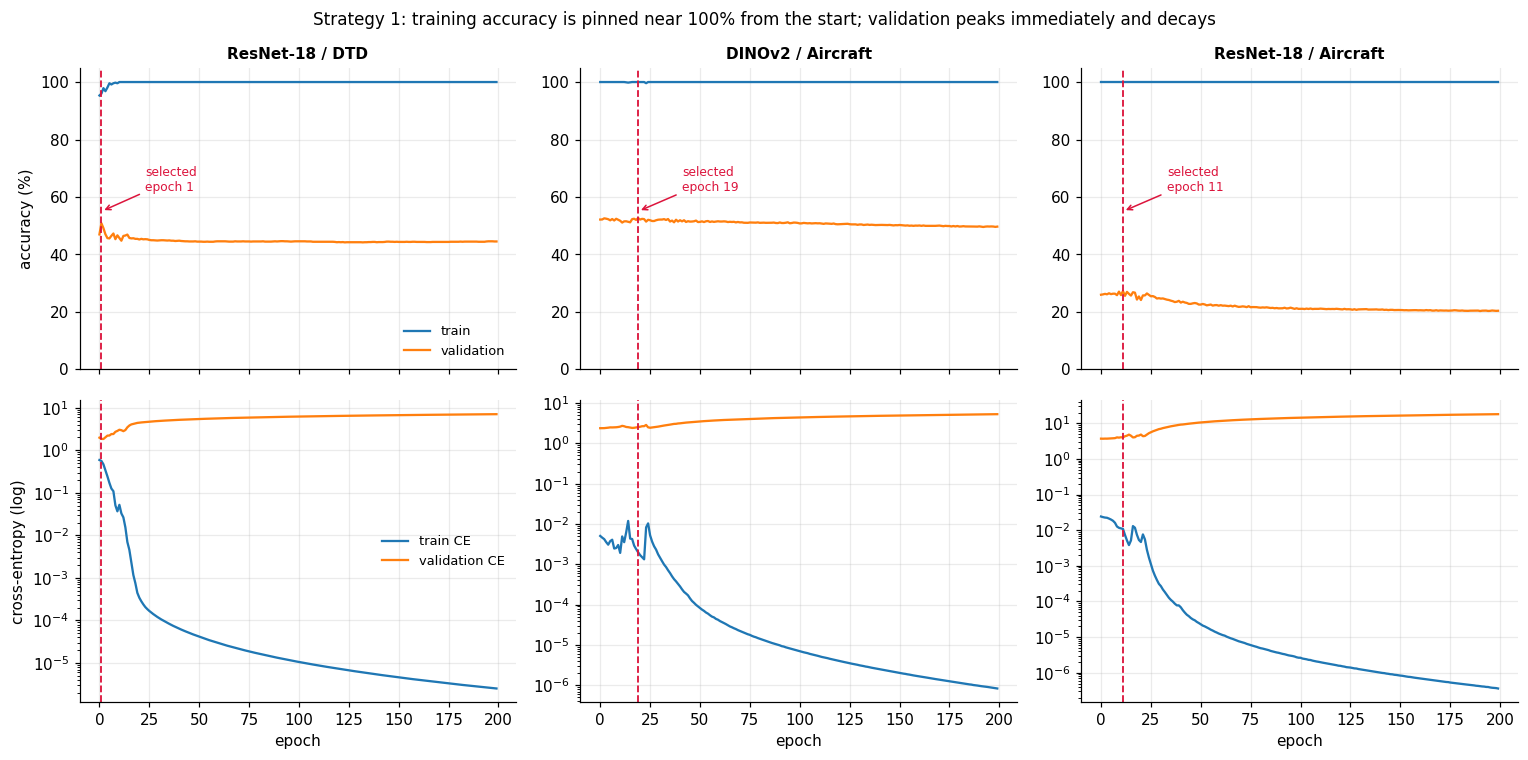

In [11]:
fig, axes = plt.subplots(2, 3, figsize=(14, 7), sharex=True)
for col, (encoder, dataset) in enumerate(COMBOS):
    hist = all_curves[f"main__{encoder}__{dataset}__K{K_SHOT}__seed0"]
    epochs = np.arange(len(hist["train_acc"]))
    sel = int(main_df[(main_df.encoder == encoder) & (main_df.dataset == dataset)
                      & (main_df.seed == 0)]["best_epoch"].iloc[0])

    ax = axes[0, col]
    ax.plot(epochs, np.array(hist["train_acc"]) * 100, label="train")
    ax.plot(epochs, np.array(hist["val_acc"]) * 100, label="validation")
    ax.axvline(sel, color="crimson", ls="--", lw=1.2)
    ax.annotate(f"selected\nepoch {sel}", (sel, 55), xytext=(sel + 22, 62), fontsize=8,
                color="crimson", arrowprops=dict(arrowstyle="->", color="crimson", lw=1))
    ax.set_title(COMBO_LABEL[(encoder, dataset)], fontsize=10)
    ax.set_ylabel("accuracy (%)" if col == 0 else "")
    ax.set_ylim(0, 105)
    if col == 0:
        ax.legend(fontsize=8.5)

    ax = axes[1, col]
    ax.plot(epochs, hist["train_cls_loss"], label="train CE")
    ax.plot(epochs, hist["val_loss"], label="validation CE")
    ax.axvline(sel, color="crimson", ls="--", lw=1.2)
    ax.set_yscale("log")
    ax.set_xlabel("epoch")
    ax.set_ylabel("cross-entropy (log)" if col == 0 else "")
    if col == 0:
        ax.legend(fontsize=8.5)

fig.suptitle("Strategy 1: training accuracy is pinned near 100% from the start; "
             "validation peaks immediately and decays", fontsize=11)
fig.tight_layout()
art.figure(fig, "training_curves")
plt.show()

## 7 · Results

  saved plot  -> plots/strategy1_results.png


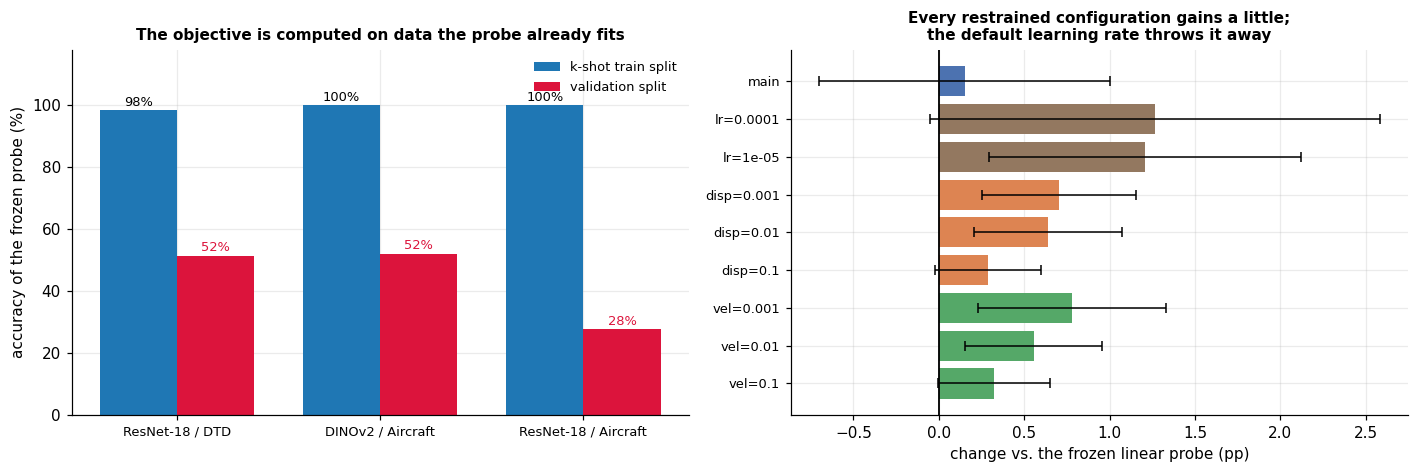

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

# (a) why there is nothing to optimise
ax = axes[0]
xs = np.arange(len(ORDER))
tr = [diag_summary[(diag_summary.encoder == e) & (diag_summary.dataset == d)]["train_acc"].iloc[0] * 100
      for e, d in COMBOS]
va = [diag_summary[(diag_summary.encoder == e) & (diag_summary.dataset == d)]["val_acc"].iloc[0] * 100
      for e, d in COMBOS]
ax.bar(xs - 0.19, tr, 0.38, label="k-shot train split")
ax.bar(xs + 0.19, va, 0.38, label="validation split", color="crimson")
for i, (t, v) in enumerate(zip(tr, va)):
    ax.annotate(f"{t:.0f}%", (i - 0.19, t + 1.5), ha="center", fontsize=8.5)
    ax.annotate(f"{v:.0f}%", (i + 0.19, v + 1.5), ha="center", fontsize=8.5, color="crimson")
ax.set_xticks(xs); ax.set_xticklabels(ORDER, fontsize=8.5)
ax.set_ylabel("accuracy of the frozen probe (%)")
ax.set_ylim(0, 118)
ax.set_title("The objective is computed on data the probe already fits", fontsize=10)
ax.legend(fontsize=8.5)

# (b) every configuration
ax = axes[1]
cfg = reg_summary.dropna(subset=["delta_pp"])
ys = np.arange(len(cfg))
colors = ["#4C72B0" if c == "main" else "#937860" if c.startswith("lr")
          else "#DD8452" if c.startswith("disp") else "#55A868" for c in cfg["config"]]
ax.barh(ys, cfg["delta_pp"], xerr=cfg["delta_std"], color=colors,
        error_kw=dict(lw=1, capsize=3))
ax.axvline(0, color="black", lw=1.2)
ax.set_yticks(ys); ax.set_yticklabels(cfg["config"], fontsize=8.5)
ax.invert_yaxis()
ax.set_xlabel("change vs. the frozen linear probe (pp)")
ax.set_title("Every restrained configuration gains a little;\n"
             "the default learning rate throws it away", fontsize=10)

fig.tight_layout()
art.figure(fig, "strategy1_results")
plt.show()

  saved plot  -> plots/strategy1_displacement.png


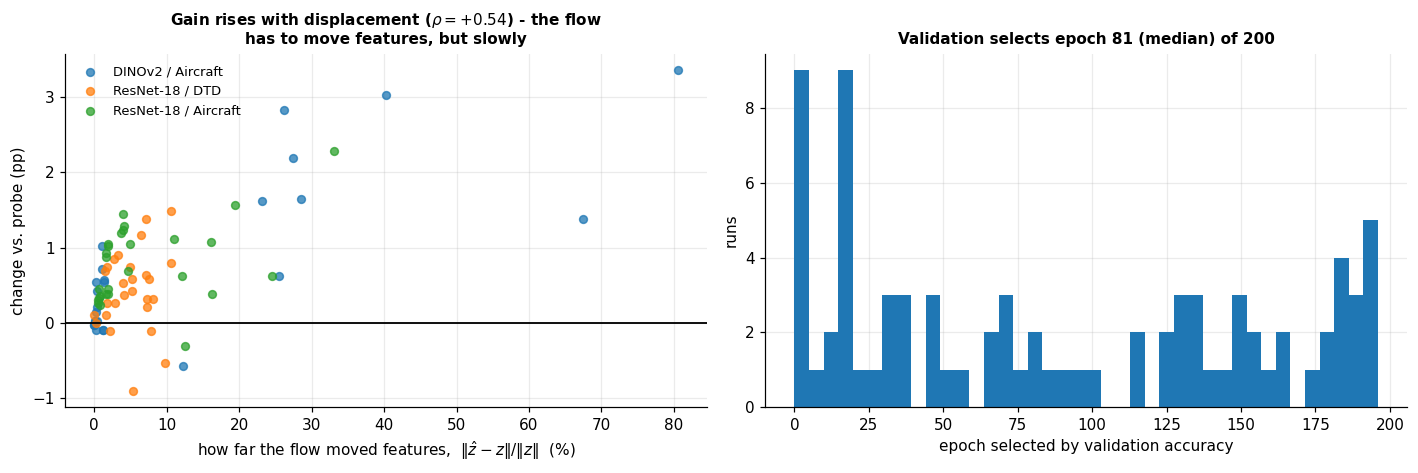

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.4))

# (a) displacement vs delta
ax = axes[0]
for (encoder, dataset), grp in runs.groupby(["encoder", "dataset"]):
    ax.scatter(grp["relative_displacement"] * 100, grp["delta_pp"], s=26, alpha=0.75,
               label=COMBO_LABEL[(encoder, dataset)])
ax.axhline(0, color="black", lw=1.2)
ax.set_xlabel(r"how far the flow moved features,  $\|\hat z - z\| / \|z\|$  (%)")
ax.set_ylabel("change vs. probe (pp)")
ax.set_title("Gain rises with displacement " + r"($\rho = +0.54$)" + " - the flow\n"
             "has to move features, but slowly", fontsize=10)
ax.legend(fontsize=8.5)

# (b) selected epoch
ax = axes[1]
ax.hist(runs["best_epoch"], bins=40)
ax.set_xlabel("epoch selected by validation accuracy")
ax.set_ylabel("runs")
ax.set_title(f"Validation selects epoch {runs['best_epoch'].median():.0f} (median) "
             f"of {MAIN.max_epochs}", fontsize=10)

fig.tight_layout()
art.figure(fig, "strategy1_displacement")
plt.show()

## 8 · Saving

In [14]:
torch.save({
    "runs": runs.to_dict("records"),
    "curves": all_curves,
    "config_main": MAIN.as_dict(),
    "diagnostic": diag.to_dict("records"),
}, RESULTS_ROOT / "strategy1_runs.pt")
print(f"saved -> {RESULTS_ROOT / 'strategy1_runs.pt'} "
      f"({(RESULTS_ROOT / 'strategy1_runs.pt').stat().st_size / 1024:.0f} KB)")
art.manifest()

saved -> C:\Users\youse\Project in Computer Vision\ProjectInComputerVision\Stage_3\results\strategy1_runs.pt (878 KB)
10 artefacts in C:\Users\youse\Project in Computer Vision\ProjectInComputerVision\Stage_3\Work\02_end_to_end


,kind,file,size_KB
0,plot,plots/strategy1_displacement.png,78.4
1,plot,plots/strategy1_results.png,72.8
2,plot,plots/training_curves.png,140.6
3,table,tables/objective_diagnostic.csv,1.2
4,table,tables/objective_diagnostic_summary.csv,0.4
5,table,tables/strategy1_all_runs.csv,16.9
6,table,tables/strategy1_best_config_summary.csv,0.3
7,table,tables/strategy1_config_summary.csv,0.8
8,table,tables/strategy1_learning_rate_sweep.csv,0.8
9,table,tables/strategy1_main_summary.csv,0.4


In [15]:
restrained = runs[runs["config"] != "main"]
print("Step 02 complete.\n")
print(f"  {len(runs)} runs across {runs['config'].nunique()} configurations "
      f"({runs['elapsed_s'].sum() / 60:.1f} min of training)")
print(f"  default lr (1e-3)       : {main_df['delta_pp'].mean():+.2f} pp - overfits before "
      f"validation accuracy can rise")
print(f"  best configuration      : {best['config']}  "
      f"({best['delta_pp']:+.2f} +/- {best['delta_std']:.2f} pp vs the probe)")
print(f"  restrained configs      : {(restrained['delta_pp'] > 0).sum()}/{len(restrained)} "
      f"runs improve on the probe")
print(f"  CE(train) at identity   : "
      f"{diag_summary['ce_train'].min():.4f} to {diag_summary['ce_train'].max():.4f} "
      f"- and it anti-predicts the gain")
print("\nNext: step 03 trains Strategy 2, classifier-guided targets with standard FM.")

Step 02 complete.

  81 runs across 9 configurations (27.4 min of training)
  default lr (1e-3)       : +0.15 pp - overfits before validation accuracy can rise
  best configuration      : lr=0.0001  (+1.27 +/- 1.32 pp vs the probe)
  restrained configs      : 63/72 runs improve on the probe
  CE(train) at identity   : 0.0052 to 0.3266 - and it anti-predicts the gain

Next: step 03 trains Strategy 2, classifier-guided targets with standard FM.
